Dummy dataset of different clusters with a neural network that attempts to predict the membership of points to each cluster. The network is optimized using the `genalg` module.

In [2]:
import numpy as np
import numpy.typing as npt
from matplotlib import pyplot as plt
from algorithms.neural.nn import Layer, NeuralNetwork
from algorithms.neural.plotting import NetworkPlotter
from algorithms.genalg import GeneticAlgorithm, selection, crossover, mutation
import tqdm.notebook as tqdm

# Functions

## Data generation

In [3]:
def create_clusters(
        num_clusters: int, num_points_per_cluster: int,
        min_distance: float) -> npt.NDArray[np.float64]:
    """
    Generate a number of points that have membership to a given number of clusters.
    """
    clusters = np.zeros((num_clusters, num_points_per_cluster, 2))
    cluster_centers = np.zeros((0,2))
    for cluster_idx in range(num_clusters):
        attempt=0
        while True:
            attempt +=1
            assert attempt < 1000, "number of attempt exceeded."
            center = np.random.uniform(-1, 1, 2)
            distances = np.linalg.norm(cluster_centers  - center, axis=1)
            if distances.shape[0]==0 or distances.min() > min_distance:
                break
        
        cluster_centers = np.vstack([cluster_centers, center])
        spread = np.random.uniform(0.05, 0.25)
        clusters[cluster_idx] = np.random.normal(center, spread, (num_points_per_cluster,2))
    return clusters


def plot_clusters(clusters: npt.NDArray[np.float64]):
    """
    Visualize the points for each cluster.
    """
    fig, axs = plt.subplots(figsize=(8,4), ncols=2)
    for cluster_idx, cluster_points in enumerate(clusters):
        axs[0].scatter(*cluster_points.T, alpha=0.3, s=5)
    axs[1].scatter(*clusters.reshape((-1,2)).T, alpha=0.3, s=5, color="black")
    for ax in axs:
        ax.set_xlim((-1.5, 1.5))
        ax.set_ylim((-1.5, 1.5))
    fig.tight_layout()
    plt.show()


def get_membership(clusters: npt.NDArray[np.float64]) -> npt.NDArray[np.int64]:
    """
    Create a DataFrame of (x,y) points and their cluster membership.
    """
    return np.repeat(np.arange(clusters.shape[0]), clusters.shape[1])


def flatten_points(clusters: npt.NDArray[np.float64]) -> npt.NDArray[np.float64]:
    """
    Flatten the list of points of each cluster to a single list of points.
    """
    return clusters.reshape((-1, 2))

## GA and NN initialization

In [4]:
def initialize_nn(
        num_clusters: int, num_hidden_layers: int, hidden_layer_dim: int) -> NeuralNetwork:
    network = NeuralNetwork(input_dim=2)
    network.add_layer(Layer(size=hidden_layer_dim, input_dim=2))
    for _ in range(num_hidden_layers - 1):
        network.add_layer(
            Layer(size=hidden_layer_dim, input_dim=hidden_layer_dim))
    network.add_layer(Layer(size=num_clusters, input_dim=hidden_layer_dim))
    return network


def initialize_ga(
        tournament_k: int, mutation_probability: float, num_elites: int) -> GeneticAlgorithm:
    ga = GeneticAlgorithm(
        selection=selection.Tournament(k=tournament_k),
        crossover=crossover.Multipoint(n=4),
        mutations=[mutation.UniformReplacement(p=mutation_probability)],
        num_elites=num_elites)
    return ga


def initialize_population(
        pop_size: int, genome_size: int) -> npt.NDArray[np.float64]:
    """
    Create a population of a given number of random NN parameters.
    """
    population = np.random.uniform(-1, 1, (pop_size, genome_size))
    return population   

## Training

In [5]:
def predict_points(
        points: npt.NDArray[np.float64], network: NeuralNetwork) -> npt.NDArray[np.int64]:
    """
    Use the neural network to predict a list of points.
    """
    predicted_clusters = np.zeros(points.shape[0], dtype=np.int64)
    for i, xy in enumerate(points):
        output_values, selection = network.forward_pass(xy)
        predicted_clusters[i] = selection
    return predicted_clusters


def evaluate_population_fitness(
        points: npt.NDArray[np.float64], membership: npt.NDArray[np.int64], 
        population: npt.NDArray[np.float64], network: NeuralNetwork) -> npt.NDArray[np.float64]:
    """
    Use the genomes of a population to predict each point and return the accuracy.
    """
    population_fitness = np.zeros(population.shape[0])

    for i, genome in enumerate(population):
        network.set_genome(genome)
        predicted_clusters = predict_points(points, network)
        accuracy = (predicted_clusters == membership).mean()
        population_fitness[i] = accuracy
    
    return population_fitness


def train_network(
        network: NeuralNetwork, ga: GeneticAlgorithm, points: npt.NDArray[np.float64], 
        membership: npt.NDArray[np.int64], population: npt.NDArray[np.int64], 
        num_iterations: int) -> tuple[npt.NDArray]:
    log_fitness = np.zeros((num_iterations, len(population)))
    log_genomes = np.zeros((num_iterations, len(population), network.genome_size))

    for i in tqdm.trange(num_iterations):
        fitness = evaluate_population_fitness(points, membership, population, network)
        log_fitness[i] = fitness
        log_genomes[i] = population
        population = ga.evolve_population(population, fitness)
        
        # if i % int(num_iterations / 20) == 0:
        #     print(f"gen {i}/{num_iterations} ({round(100*i/num_iterations,0)}%) | best = {fitness.max().round(4)}")

    return log_fitness, log_genomes

## Testing and analysis

In [6]:
def plot_test_results(
        points: npt.NDArray[np.float64], membership: npt.NDArray[np.int64], 
        predicted_membership: npt.NDArray[np.int64]):
    """
    Plot the points in the test dataset with with highlighted errors.
    """
    is_correct = membership == predicted_membership
    fig, ax = plt.subplots(figsize=(5,5))

    # Print correct predictions
    for cluster in np.unique(membership):
        plot_points = points[(is_correct) & (membership==cluster)]
        ax.scatter(*plot_points.T, s=5, alpha=0.5, label=cluster)

    # Print incorrect predictions
    for cluster in np.unique(membership):
        plot_points = points[(~is_correct) & (membership==cluster)]
        ax.scatter(*plot_points.T, s=30, alpha=0.35, color="red")

    ax.legend()
    plt.show()


def plot_behavior_grid(network: NeuralNetwork, grid_resolution: int):
    """
    Visualize the probablity of points being assigned to each cluster in the nn.
    """
    num_clusters = network.layers[-1].size
    n = grid_resolution
    grid = np.transpose(-1.5 + (3*np.indices((n,n))/n))
    predictions = np.zeros((n, n, num_clusters))

    for i in range(n):
        for j in range(n):
            output_values, selection = network.forward_pass(grid[i,j])
            predictions[i,j] = output_values

    fig, axs = plt.subplots(ncols=num_clusters, figsize=(2*num_clusters, 3))
    for i in range(num_clusters):
        axs[i].imshow(predictions[:,:,i], origin="lower", cmap="Greys")
        axs[i].set_title(f"cluster {i}")
        axs[i].set_xticks([])
        axs[i].set_yticks([])
    
    fig.tight_layout()
    plt.show()
    return predictions


def plot_grid_predictions(predictions):
    """
    Plot predicted cluster for each point in the grid
    """
    fig, ax = plt.subplots(figsize=(5,5))

    n = predictions.shape[0]
    grid_highest_cluster = np.zeros((n,n))
    for i in range(n):
        for j in range(n):
            grid_highest_cluster[i,j] = predictions[i,j].argmax()

    ax.imshow(grid_highest_cluster, origin="lower", cmap="Greys")
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_title("Cluster selection for evenly spaced out cells")
    plt.show()

# NN optimization

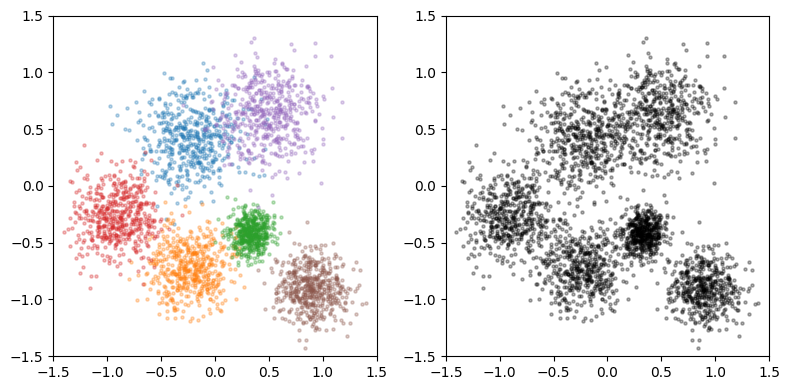

In [24]:
# Create a dummy dataset of cluster
clusters = create_clusters(num_clusters=6, num_points_per_cluster=500, min_distance=0.6)
points = flatten_points(clusters)
membership = get_membership(clusters)
plot_clusters(clusters)

In [32]:
# Initialize alorithms and population
network = initialize_nn(
    num_clusters=clusters.shape[0],
    num_hidden_layers=2,
    hidden_layer_dim=8)

initial_population = initialize_population(
    pop_size=100,
    genome_size=network.genome_size)

ga = initialize_ga(
    tournament_k=5,
    mutation_probability=0.03,
    num_elites=1)

# Train test split on points
test_frac = 0.8
mask = np.random.uniform(size=points.shape[0]) < test_frac
points_train = points[mask]
points_test = points[~mask]
membership_train = membership[mask]
membership_test= membership[~mask]

# Train network
log_fitness, log_genomes = train_network(
    network, ga, points_train, membership_train, initial_population, num_iterations=200)

  0%|          | 0/200 [00:00<?, ?it/s]

# Analysis

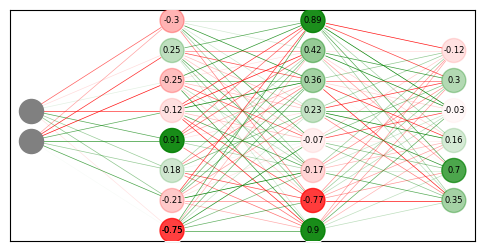

In [33]:
# Extract and plot the best network
best_idx = np.unravel_index(log_fitness.argmax(), log_fitness.shape)
network.set_genome(log_genomes[best_idx])

fig, ax = plt.subplots(figsize=(6,3))
plotter = NetworkPlotter(network, scale=1)
plotter.pyplot_structure(ax, node_size=300, font_size=6, font_offset=(0,0))
plt.show()

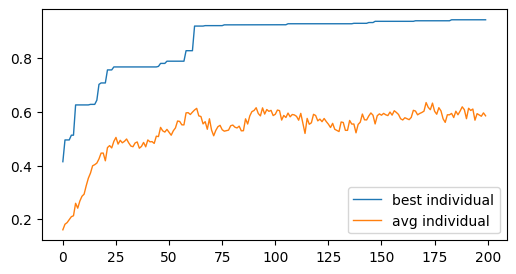

In [34]:
fig, ax = plt.subplots(figsize=(6,3))
ax.plot(log_fitness.max(axis=1), label="best individual", linewidth=1)
ax.plot(log_fitness.mean(axis=1), label="avg individual", linewidth=1)
ax.legend()
plt.show()

In [35]:
# Evaluate the final network based on the test dataset
membership_predicted = predict_points(points_test, network)
accuracy = (membership_predicted == membership_test).mean()
accuracy

np.float64(0.9384885764499121)

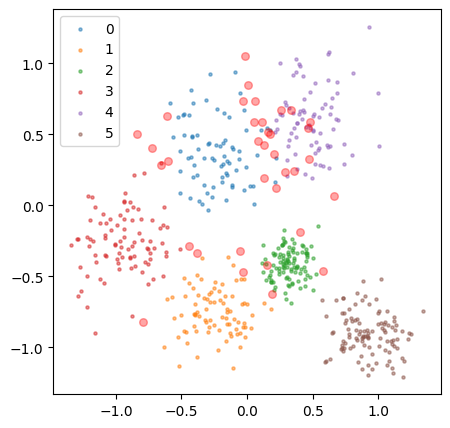

In [36]:
# Visualize errors
plot_test_results(points_test, membership_test, membership_predicted)

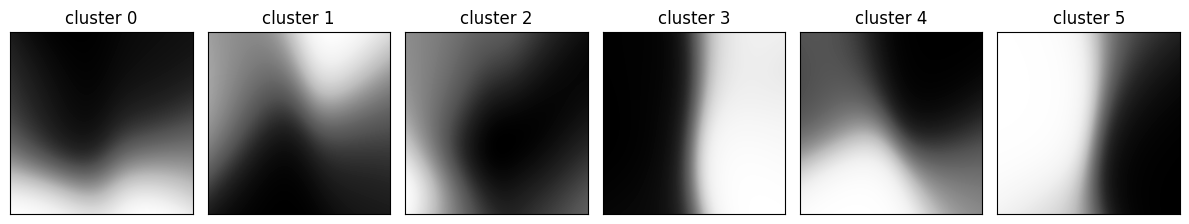

In [39]:
# Visualize prediction behavior for all locations in the grid
predictions = plot_behavior_grid(network, grid_resolution=500)

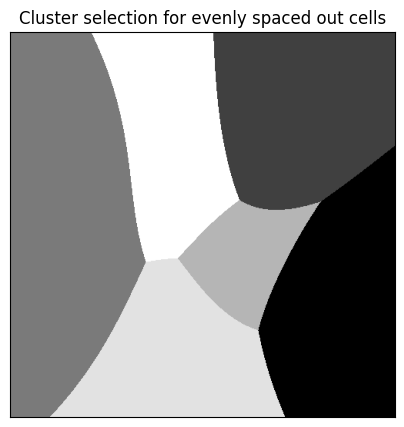

In [40]:
plot_grid_predictions(predictions)